<a href="https://colab.research.google.com/github/ValbertoFeitosa/image-classification-machine-learning/blob/main/image_classification_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## O notebook mostra exemplos de como trabalhar com o Teorema de Naive Bayes para a classificação de imagens.

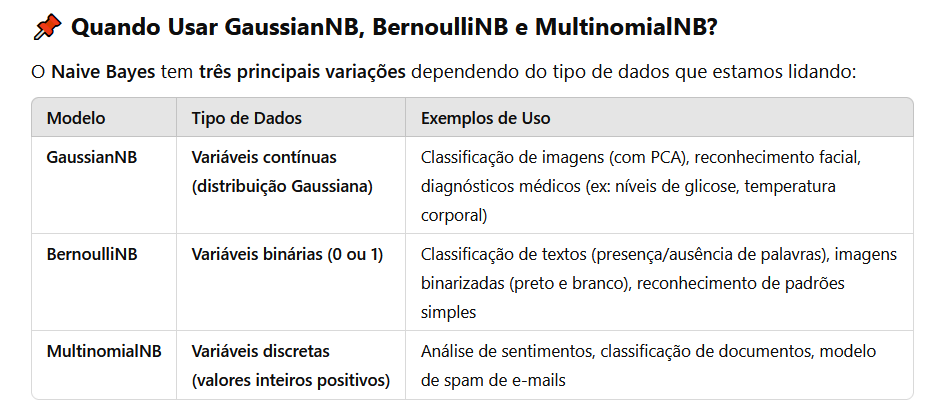

## **Classificação de Imagens sem Redes Neurais Pré-Treinadas.**

In [ ]:
# Importa o módulo drive da biblioteca google.colab, que permite acessar o Google Drive diretamente no ambiente do Google Colab.
from google.colab import drive

# Monta o Google Drive no diretório '/content/drive', criando um ponto de montagem local no sistema de arquivos do Colab.
# Isso permite que o usuário acesse arquivos do seu Google Drive como se estivessem em um diretório local.
drive.mount('/content/drive')

Mounted at /content/drive


## IMPORTANTO BIBLIOTECAS

In [ ]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 13.0 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 169.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 23.6 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
from tensorflow.keras.preprocessing import image
print("keras.preprocessing.image OK")


keras.preprocessing.image OK


In [ ]:
# Importação de bibliotecas para análise de dados e aprendizado de máquina

# Módulos para redução de dimensionalidade
from sklearn.manifold import TSNE  # t-Distributed Stochastic Neighbor Embedding (t-SNE) para visualização de alta dimensão
from sklearn.decomposition import PCA  # Análise de Componentes Principais (PCA) para redução de dimensionalidade

# Módulos para particionamento de dados e validação cruzada
from sklearn.model_selection import train_test_split  # Divisão dos dados em conjunto de treino e teste
from sklearn.model_selection import cross_val_score, cross_val_predict  # Validação cruzada para avaliação de modelos

# Modelos de aprendizado de máquina
from sklearn.neighbors import KNeighborsClassifier  # Algoritmo K-Nearest Neighbors (KNN)
from sklearn.naive_bayes import GaussianNB  # Classificador Naive Bayes Gaussiano
from sklearn.linear_model import LogisticRegression, SGDClassifier  # Regressão logística e classificador baseado em gradiente descendente estocástico
from xgboost import XGBClassifier  # Classificador XGBoost para aprendizado de máquina baseado em árvores
from sklearn.ensemble import RandomForestClassifier  # Classificador Random Forest (floresta aleatória)

# Módulos para avaliação de modelos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Matriz de confusão e sua exibição gráfica

# Módulo para pré-processamento de dados
from sklearn import preprocessing  # Ferramentas para normalização e padronização de dados

# Módulo para pré-processamento de imagens com TensorFlow/Keras
from tensorflow.keras.preprocessing import image  # Manipulação e carregamento de imagens para deep learning

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt  # Biblioteca principal para criação de gráficos
import pandas as pd  # Manipulação e análise de dados em DataFrames
import numpy as np  # Operações matemáticas e manipulação de arrays
import seaborn as sns  # Biblioteca para visualizações estatísticas avançadas

# Módulo para interação com o sistema operacional
import os  # Facilita operações de arquivos e diretórios no sistema


In [ ]:
# Definição de parâmetros para a divisão do conjunto de dados
percentege_test_size = 0.2  # Proporção dos dados reservados para o conjunto de teste (20%)

# Parâmetro para undersampling
undersampling_size = -1  # Definir -1 para não realizar undersampling, caso contrário, define o número de amostras por classe

# Parâmetros para pré-processamento de imagens
largura = 64  # Largura desejada das imagens após o redimensionamento
altura = 64  # Altura desejada das imagens após o redimensionamento
modo_de_cor = 'rgb'  # Modo de cor da imagem ('rgb' para colorido, 'grayscale' para tons de cinza, 'rgba' para imagens com canal alfa)

# Definição do diretório contendo as imagens de treino
# Alterar o caminho conforme necessário para apontar para o local correto no Google Drive ou sistema de arquivos
#diretorio = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P'  # Caminho alternativo comentado
diretorio = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino'  # Caminho atual para o conjunto de treino


### CARREGANDO DATASET

Explicação geral:

O código percorre o diretório principal e identifica as subpastas, que são consideradas as classes das imagens.

Para cada classe, ele lista os arquivos de imagem, excluindo arquivos irrelevantes.

Se o undersampling_size for definido com um valor positivo, limita o número de imagens por classe.

Os dados são convertidos em um numpy.array e embaralhados para evitar padrões indesejados.

Finalmente, cria-se um DataFrame do Pandas para organizar as informações.

In [ ]:
# Lista todas as subpastas dentro do diretório principal para identificar as classes de imagens
targets = [x[0].replace(diretorio, '') for x in os.walk(diretorio)]

# Remove o primeiro item da lista, pois ele representa o próprio diretório principal e não uma classe
targets = targets[1:len(targets)]

# Lista para armazenar os caminhos das imagens e suas respectivas classes
dados = []

# Percorre cada diretório correspondente a uma classe
for classe in targets:
    # Obtém a lista de imagens dentro do diretório da classe
    imagens = os.listdir(diretorio + classe)
    i = 0  # Contador para controlar o undersampling (caso seja ativado)

    # Percorre a lista de imagens
    for img in imagens:
        i += 1  # Incrementa o contador de imagens processadas

        # Filtra arquivos indesejados, como arquivos de segmentação, metadados ou arquivos de sistema
        if (not '.txt' in img) and (not 'segmentation' in img) and (not 'desktop.ini' in img):
            # Adiciona o caminho completo da imagem e sua respectiva classe à lista de dados
            dados.append([diretorio + classe + '/' + img, classe])

        # Se o undersampling estiver ativado, para após atingir o número definido
        if i == undersampling_size and undersampling_size != -1:
            break

# Converte a lista para um array NumPy para facilitar o embaralhamento e manipulação
dados = np.array(dados)

# Embaralha os dados para evitar viés na ordem das amostras
np.random.shuffle(dados)

# Cria um DataFrame do Pandas com os caminhos das imagens e seus rótulos
df_dados = pd.DataFrame(dados, columns=['image', 'target'])

# Exibe o DataFrame resultante
df_dados


,image,target
0,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
1,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/cachorro
2,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/raposa
3,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
4,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
...,...,...
145,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/coelho
146,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
147,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/coelho
148,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/gato


In [ ]:
# Seleciona o caminho da primeira imagem no DataFrame
img_path = df_dados.iloc[0]["image"]  # Pegando o caminho da primeira imagem do conjunto de dados

# Carrega a imagem a partir do caminho especificado
# target_size=(150, 150) -> Redimensiona a imagem para 150x150 pixels
# color_mode="rgb" -> Define que a imagem será carregada no formato RGB (3 canais de cor)
img = image.load_img(img_path, target_size=(largura, altura), color_mode="rgb")

# Converte a imagem carregada para um array NumPy (necessário para processamento em ML/DL)
img_array = image.img_to_array(img)

# Exibe a forma do array da imagem antes do achatamento (deve ser (largura,altura, 3))
print(f"Forma da imagem antes do achatamento: {img_array.shape}")  # Esperado: (largura,altura, 3)


Forma da imagem antes do achatamento: (64, 64, 3)


In [ ]:
dados

array([['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/pato/908903032992914.jpg',
        '/pato'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/cachorro/download (3).jpeg',
        '/cachorro'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/raposa/raposa-vermelha-14.jpg',
        '/raposa'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/pato/duck-1886235.jpg',
        '/pato'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/pato/pato.png',
        '/pato'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/cachorro/images (6).jpeg',
        '/cachorro'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/raposa

In [ ]:
!pip install opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 50.1 MB/s eta 0:00:00


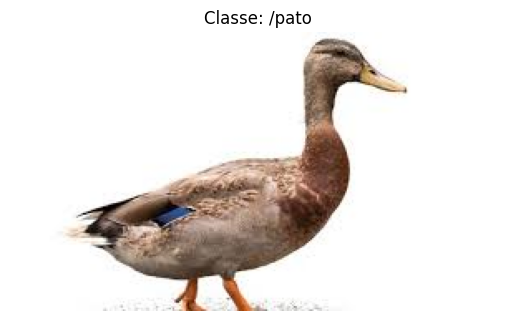

 Informações da Imagem:
 Caminho: /content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/gatos-patos-caes-rapozas-coelhos/treino/pato/download (2).jpeg
 Dimensões: 299x168 pixels
 Canais de cor: 3
 Tipo dos pixels: uint8


In [ ]:
# Importação das bibliotecas necessárias
import cv2  # OpenCV para manipulação de imagens
import numpy as np  # NumPy para operações com arrays
import matplotlib.pyplot as plt  # Matplotlib para visualização
from PIL import Image  # PIL para manipulação avançada de imagens

# Seleciona uma amostra aleatória do dataset
amostra = df_dados.sample(1)  # Escolhe uma imagem aleatória do DataFrame
img_path = amostra["image"].values[0]  # Obtém o caminho da imagem selecionada
label = amostra["target"].values[0]  # Obtém a classe (rótulo) associada à imagem

# Carrega a imagem usando OpenCV
img = cv2.imread(img_path)  # OpenCV lê a imagem no formato BGR (Blue-Green-Red)

# Verifica as dimensões da imagem carregada
altura, largura, canais = img.shape  # Obtém altura, largura e número de canais de cor
tipo_dado = img.dtype  # Obtém o tipo de dados dos pixels da imagem

# Converte a imagem de BGR para RGB para exibição correta no Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Exibe a imagem usando Matplotlib
plt.imshow(img_rgb)  # Plota a imagem convertida para RGB
plt.title(f"Classe: {label}")  # Define o título da imagem com a classe correspondente
plt.axis("off")  # Remove os eixos para melhor visualização
plt.show()  # Exibe a imagem

# Exibe as informações da imagem carregada
print(f" Informações da Imagem:")
print(f" Caminho: {img_path}")  # Exibe o caminho do arquivo de imagem
print(f" Dimensões: {largura}x{altura} pixels")  # Exibe a resolução da imagem
print(f" Canais de cor: {canais}")  # Número de canais (3 = RGB, 1 = escala de cinza)
print(f" Tipo dos pixels: {tipo_dado}")  # Tipo de dados armazenados nos pixels (ex: uint8)


1132 × 766 × 3 = 2.6 milhões de características

In [ ]:
# Conta a quantidade de imagens por classe (categoria) no conjunto de dados
# Retorna uma série Pandas onde:
# - O índice representa cada classe presente na coluna 'target'
# - Os valores representam o número de amostras (imagens) pertencentes a cada classe
df_dados['target'].value_counts()


,count
target,
/pato,30
/cachorro,30
/raposa,30
/gato,30
/coelho,30


## **Caso estejamos trabalhando com os dados da pneumonia.**

In [ ]:
# Filtrar imagens da classe NORMAL e PNEUMONIA
df_normal = df_dados[df_dados["target"] == "/NORMAL"].sample(n=500, random_state=42)
df_pneumonia = df_dados[df_dados["target"] == "/PNEUMONIA"].sample(n=500, random_state=42)

# Concatenar os dois subconjuntos para formar um novo dataset balanceado
df_selecionado = pd.concat([df_normal, df_pneumonia]).reset_index(drop=True)

# Mostrar a contagem de cada classe no novo dataset
print(df_selecionado["target"].value_counts())


In [ ]:
# Converte o DataFrame Pandas 'df_selecionado' em um array NumPy
dados2 = np.array(df_selecionado)

# Exibe o array resultante
dados2


array([['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/NORMAL/NORMAL2-IM-0939-0001.jpeg',
        '/NORMAL'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/NORMAL/IM-0543-0001.jpeg',
        '/NORMAL'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/NORMAL/NORMAL2-IM-1196-0001.jpeg',
        '/NORMAL'],
       ...,
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/PNEUMONIA/person326_bacteria_1505.jpeg',
        '/PNEUMONIA'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/PNEUMONIA/person1669_bacteria_4422.jpeg',
        '/PNEUMONIA'],
       ['/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/P/PNEUMONIA/person395_bacteria_1795.jpeg',
        '/PNEUMONIA']], dtype=object)

## PREPARANDO DADOS

In [ ]:
def embedding(img_path, largura, altura, modo_de_cor):
    """
    Carrega uma imagem, redimensiona, normaliza e a converte para um vetor achatado.

    Parâmetros:
    - img_path (str): Caminho da imagem no sistema de arquivos.
    - largura (int): Largura desejada para a imagem redimensionada.
    - altura (int): Altura desejada para a imagem redimensionada.
    - modo_de_cor (str): Modo de cor da imagem ('grayscale' para tons de cinza, 'rgb' para colorido, 'rgba' para colorido com canal alfa).

    Retorna:
    - numpy.ndarray: Vetor 1D contendo os valores normalizados dos pixels da imagem.
    """

    # Carrega a imagem do caminho especificado, redimensionando e convertendo para o modo de cor desejado
    img = image.load_img(img_path, target_size=(largura, altura), color_mode=modo_de_cor)

    # Converte a imagem carregada para um array NumPy
    embed = image.img_to_array(img)

    # Normaliza os valores dos pixels para o intervalo [0, 1]
    embed = embed / 255.0

    # Achata a matriz da imagem em um vetor 1D para facilitar o uso em modelos de ML/DL
    return embed.flatten()


In [ ]:
# Obtém a coluna 'target' como um array de valores a partir do DataFrame df_dados
# Nota: A linha comentada refere-se ao uso de df_selecionado, mas a versão ativa utiliza df_dados
#target = df_selecionado['target'].array  # Linha comentada (possível versão alternativa)-pneumonia
target = df_dados['target'].array  # Utilizando df_dados para obter os rótulos das classes

# Lista para armazenar as características extraídas das imagens
array_features = []

# Percorre os dados e extrai as características de cada imagem
# A linha comentada (for x in dados2) sugere que inicialmente usava um conjunto diferente de dados
#for x in dados2:  # Linha comentada (alternativa de iteração)- pneumonia
for x in dados:  # Itera sobre os dados extraindo as características de cada imagem
    array_features.append(embedding(x[0], largura, altura, modo_de_cor))
    # Aplica a função 'embedding' para extrair as características da imagem

# Normaliza os dados extraídos utilizando padronização (média 0 e desvio padrão 1)
scaler = preprocessing.StandardScaler()  # Criação do objeto StandardScaler para normalização
array_features = scaler.fit_transform(array_features)  # Aplica a normalização nos dados extraídos

# Converte o array de características normalizadas para um DataFrame do Pandas
df_features = pd.DataFrame(array_features)

# Exibe o DataFrame contendo as características extraídas e normalizadas
df_features


,0,1,2,3,4,5,6,7,8,9,...,150686,150687,150688,150689,150690,150691,150692,150693,150694,150695
0,-0.451873,-0.584823,-0.593574,-0.211589,-0.326072,-0.308572,-0.442324,-0.546280,-0.464556,-0.546994,...,0.111134,0.062539,0.023616,0.151501,0.093051,0.043186,0.182580,0.225052,0.175128,0.290279
1,-1.007667,-0.490656,-1.218557,-0.937332,-0.420054,-1.096516,-0.429301,0.098510,-0.572166,-0.833106,...,-0.886114,-1.339825,-1.285220,-0.898873,-1.401915,-1.373398,-0.902917,-1.278051,-1.306273,-0.814717
2,-0.400172,-0.948039,-0.845971,-0.133830,-0.943668,-0.965192,0.052523,-0.788076,-1.014563,0.220306,...,-0.356711,-0.059998,0.621128,-0.305721,-0.926879,-0.665106,-0.815578,-0.933302,-0.396898,-0.702976
3,-0.361395,-0.302322,0.079485,-0.444863,-0.366350,-0.022047,-0.494413,-0.411949,-0.058030,-0.481969,...,-0.172035,-0.727142,-0.758840,-0.330435,-0.773191,-0.768399,-0.279068,-0.464445,-0.543571,-0.193933
4,-1.240325,-1.284351,-1.062311,-1.248364,-1.279318,-1.048762,-1.119482,-1.164204,-0.942823,-1.119219,...,0.172692,-0.114458,-0.004837,0.151501,-0.256240,-0.148643,0.032856,-0.285176,-0.382231,-0.193933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,-1.408356,-1.526495,-1.266633,-1.520518,-1.628393,-1.347226,-1.562240,-1.661229,-1.373263,-1.574397,...,-0.762997,-1.339825,-1.242541,-1.393167,-1.429858,-1.211081,-1.302180,-1.388370,-1.262271,-1.336176
146,1.267210,1.217806,1.077055,1.265817,1.217916,1.076300,1.276618,1.226891,1.089810,1.273719,...,1.182251,1.369597,1.318225,1.201875,1.406386,1.356478,1.218168,1.369616,1.319180,1.184208
147,-0.723307,-0.329226,-0.894047,-0.717017,-0.299221,-0.881622,-0.689747,-0.250752,-0.918910,-0.677045,...,-1.267777,-0.699911,-0.218234,-0.874159,-0.493758,0.072698,-0.690808,-0.326546,0.233797,-0.578819
148,1.538644,1.594475,1.629924,1.537970,1.593844,1.625473,1.550086,1.603019,1.639817,1.546826,...,1.687031,1.573825,1.631208,1.696169,1.601989,1.666356,1.704770,1.590254,1.656529,1.693251


## REDUZINDO A DIMENSIONALIDADE

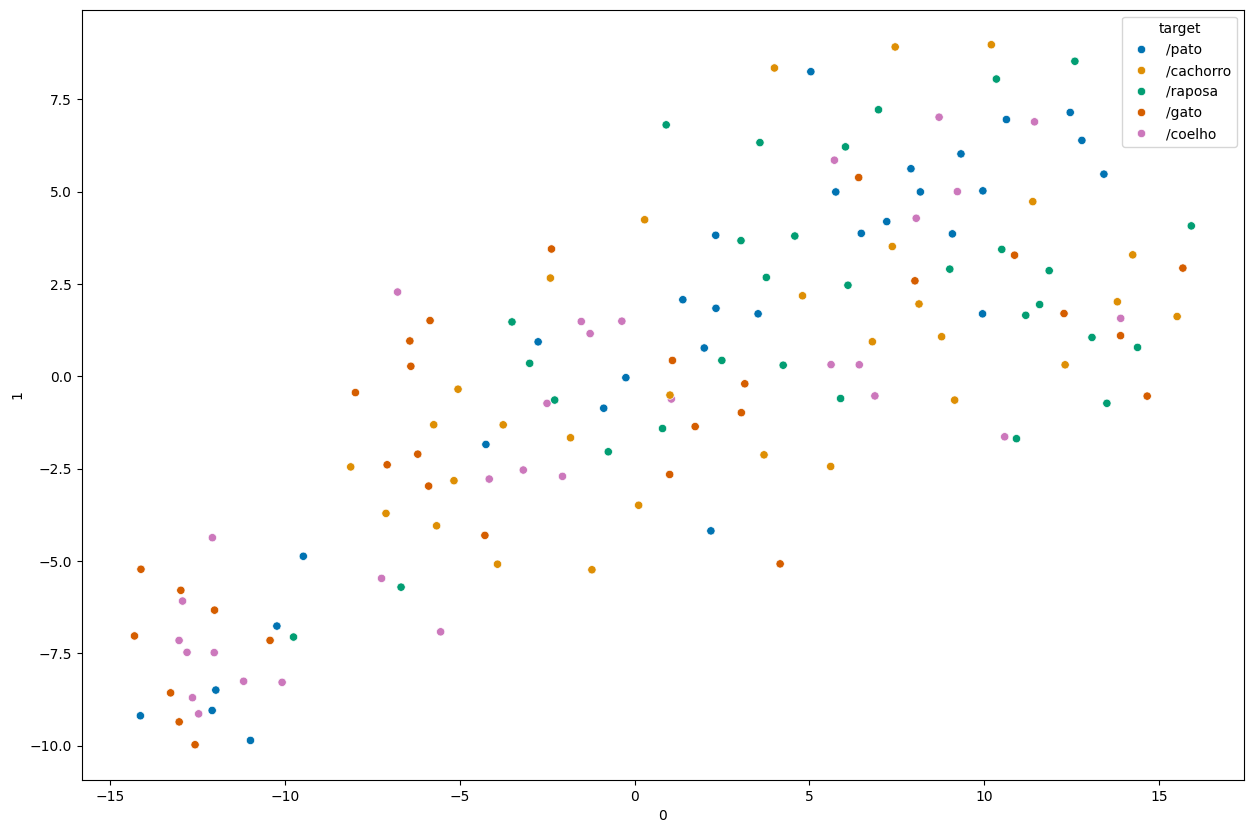

In [ ]:
# Aplicação do t-SNE para reduzir a dimensionalidade dos dados
# n_components=2 -> Reduz os dados para 2 dimensões (ideal para visualização)
# learning_rate='auto' -> Ajusta automaticamente a taxa de aprendizado
# init='random' -> Define a inicialização como aleatória para evitar viés inicial
# perplexity=15 -> Controla o número de vizinhos considerados (ajusta a preservação da estrutura local)
model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=15)

# Transforma os dados de alta dimensão (df_features) em um array de 2 dimensões
array_red = model.fit_transform(df_features)

# Criação de um DataFrame contendo os dados reduzidos
df_tsne = pd.DataFrame(array_red)

# Adiciona a coluna 'target' ao DataFrame para que possamos visualizar as classes na projeção 2D
df_tsne['target'] = target

# Configuração do tamanho da figura para melhor visualização do gráfico
plt.rcParams['figure.figsize'] = [15, 10]

# Criação do gráfico de dispersão (scatter plot) para visualizar a projeção dos dados
sns.scatterplot(data=df_tsne, x=df_tsne[0], y=df_tsne[1], hue=df_tsne['target'], palette="colorblind")

# Exibe o gráfico
plt.show()


## TREINANDO E VALIDANDO O MODELO

In [ ]:
def getModel():
    """
    Retorna um modelo de aprendizado de máquina para classificação.

    O usuário pode descomentar a linha do modelo desejado para utilizá-lo.

    Retorna:
    - Um classificador escolhido entre RandomForest, GaussianNB, Logistic Regression,
      KNN, XGBoost ou SGDClassifier.
    """

    # Retorna um classificador Naive Bayes Gaussiano (padrão)
    return GaussianNB()

    # Opções alternativas de modelos (descomente para utilizá-los):

    # Retorna um Random Forest Classifier com processamento paralelo
    # return RandomForestClassifier(n_jobs=12)

    # Retorna uma Regressão Logística com solver otimizado para grandes datasets
    # return LogisticRegression(n_jobs=20, solver='sag', multi_class='ovr')

    # Retorna um classificador KNN com 3 vizinhos e processamento paralelo
    # return KNeighborsClassifier(n_neighbors=3, n_jobs=20)

    # Retorna um classificador baseado em XGBoost
    # return XGBClassifier()

    # Retorna um SGDClassifier com early stopping e validação de 5% dos dados
    # return SGDClassifier(n_jobs=20, early_stopping=True, validation_fraction=0.05)


In [ ]:
# Divisão dos dados em conjunto de treino e teste
# - df_features.values -> Matriz de características extraídas das imagens (X)
# - target -> Rótulos das classes associadas a cada imagem (y)
# - test_size=percentege_test_size -> Define a proporção dos dados usados para teste (ex: 20% se percentege_test_size=0.2)
X_treino, X_teste, y_treino, y_teste = train_test_split(df_features.values, target, test_size=percentege_test_size)

# Obtém o modelo de aprendizado de máquina escolhido e realiza o treinamento
# - getModel() -> Função que retorna um classificador, como GaussianNB, RandomForest, KNN, etc.
# - fit(X_treino, y_treino) -> Treina o modelo nos dados de treino
model = getModel().fit(X_treino, y_treino)

# Avaliação do modelo no conjunto de teste
# - score() calcula a acurácia (proporção de previsões corretas no conjunto de teste)
score = model.score(X_teste, y_teste)

# Exibe a acurácia do modelo
score


0.3

## VALIDANDO DE FORMA MAIS ELABORADA

In [ ]:
# Avaliação do modelo utilizando validação cruzada com 10 folds
# - getModel() -> Obtém o modelo de aprendizado de máquina escolhido
# - df_features.values -> Matriz de características extraídas das imagens (X)
# - target -> Rótulos das classes (y)
# - cv=10 -> Realiza uma validação cruzada com 10 divisões (folds)
scores = cross_val_score(getModel(), df_features.values, target, cv=10)

# Calcula a média dos scores obtidos na validação cruzada
np.mean(scores)


np.float64(0.29999999999999993)

Explicação do Código

    Validação Cruzada (cross_val_score):
        A validação cruzada divide os dados em 10 partes (folds).
        O modelo é treinado em 9 partes e testado na parte restante, repetindo o processo 10 vezes.
        O resultado é uma lista de 10 scores, um para cada rodada de validação.

    Cálculo da Média dos Scores:
        np.mean(scores) calcula a média das acurácias ao longo das 10 execuções da validação cruzada.
        Isso fornece uma estimativa mais confiável do desempenho do modelo, reduzindo a influência de variações causadas pela divisão dos dados.

## VISUALIZANDO A MATRIZ DE CONFUSÃO

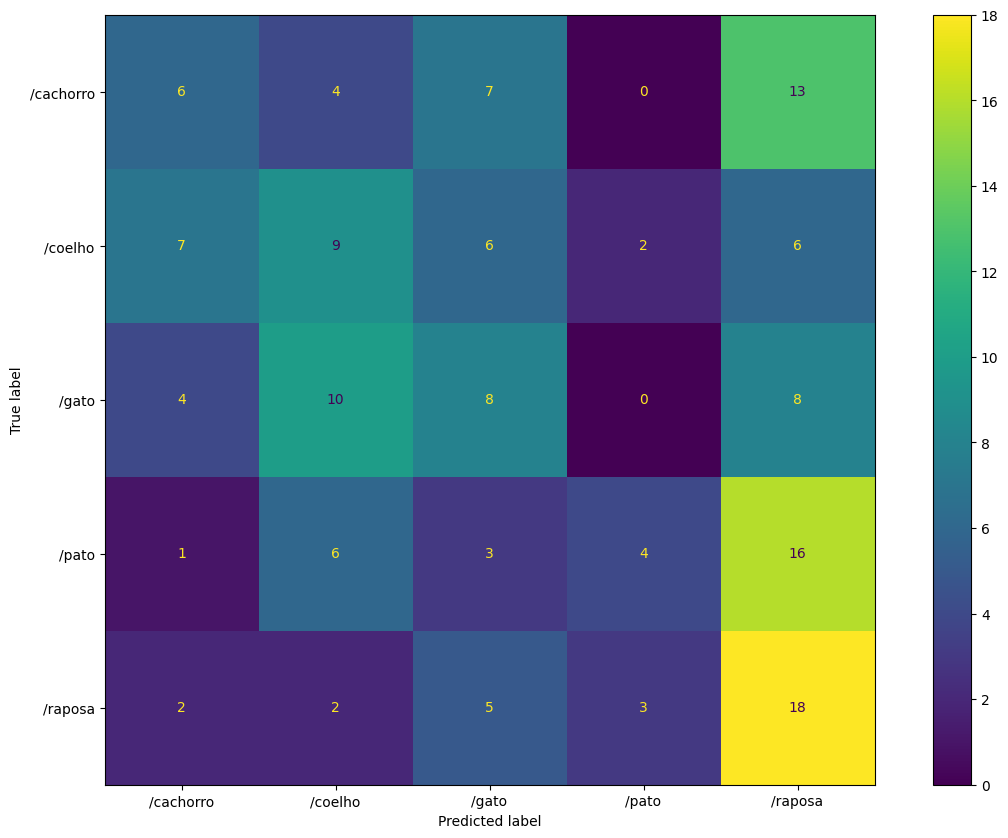

In [ ]:
# Realiza predições utilizando validação cruzada
# - getModel() -> Obtém o modelo escolhido (ex: GaussianNB, RandomForest, etc.)
# - df_features.values -> Matriz de características das imagens (X)
# - target -> Rótulos das classes (y)
# - cv=10 -> Realiza a validação cruzada com 10 folds
predicoes = cross_val_predict(getModel(), df_features.values, target, cv=10)

# Gera a matriz de confusão comparando os rótulos verdadeiros e as predições
cm = confusion_matrix(target, predicoes)

# Cria uma visualização da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

# Plota a matriz de confusão
disp.plot()

# Exibe o gráfico
plt.show()


# **Melhorando a representação das imagens**

# 1. Importação das bibliotecas


In [ ]:
# ===============================================================
# Importação de modelos pré-treinados e funções auxiliares
# ===============================================================

# Modelo InceptionV3 (rede convolucional profunda otimizada para classificação de imagens)
from tensorflow.keras.applications.inception_v3 import InceptionV3

# Modelos EfficientNet (B0 a B7) — versões com tamanhos e capacidades diferentes
# - Mais eficientes em relação a precisão e custo computacional
# - pré-treinados no ImageNet
from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,  # versão menor e mais rápida
    EfficientNetB1,
    EfficientNetB2,
    EfficientNetB3,
    EfficientNetB4,
    EfficientNetB5,
    EfficientNetB6,
    EfficientNetB7,  # versão maior e mais precisa, porém mais pesada
    preprocess_input # função para pré-processar imagens de acordo com a EfficientNet
)

# Modelo ResNet50 — Rede Residual de 50 camadas, conhecida pelo uso de "skip connections"
from tensorflow.keras.applications.resnet50 import ResNet50

# Modelo ConvNeXtBase — arquitetura moderna inspirada em CNNs e Transformers
from tensorflow.keras.applications import ConvNeXtBase

# Ferramentas para carregar e manipular imagens (ex.: redimensionar, converter para array)
from tensorflow.keras.preprocessing import image

# Biblioteca principal do TensorFlow
import tensorflow as tf


# 2. Configuração de uso de CPU ou GPU no TensorFlow

In [ ]:
# ===============================================================
# Configuração de uso de CPU ou GPU no TensorFlow
# ===============================================================

# DESCOMENTAR a linha abaixo para forçar a execução apenas na CPU
# (útil quando a GPU está indisponível ou para testes de desempenho)
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Lista todos os dispositivos físicos do tipo GPU detectados pelo TensorFlow
physical_devices = tf.config.experimental.list_physical_devices('GPU')

# Se existir pelo menos uma GPU disponível:
if len(physical_devices) > 0:
    # Define que a GPU aloque memória de forma dinâmica (apenas o necessário)
    # Isso evita o erro de "CUDA out of memory" quando a GPU reserva toda a VRAM no início
    tf.config.experimental.set_memory_growth(physical_devices[0], True)  # Necessário para CNN

# Exibe a versão do TensorFlow instalada
print('TensorFlow version: ', tf.__version__)

# Exibe o número de GPUs detectadas
print('Número de GPUs disponíveis: ', len(physical_devices))


TensorFlow version:  2.19.0
Número de GPUs disponíveis:  1


# 3. Função para selecionar o modelo de extração de embeddings

In [ ]:
# ===============================================================
# Função para selecionar o modelo de extração de embeddings
# ===============================================================
def getEmbedder():
    # Retorna o modelo EfficientNetB0 pré-treinado no ImageNet,
    # sem a camada densa final (include_top=False),
    # para ser usado como extrator de características.
    #return EfficientNetB0(weights='imagenet', include_top=False)

    # Outras opções de modelos (descomentar para testar):
     return EfficientNetB2(weights='imagenet', include_top=False)
    # return EfficientNetB3(weights='imagenet', include_top=False)
    # return EfficientNetB4(weights='imagenet', include_top=False)
    # return EfficientNetB5(weights='imagenet', include_top=False)
    # return EfficientNetB7(weights='imagenet', include_top=False)
    # return InceptionV3(weights='imagenet', include_top=False)

# ===============================================================
# Função para processar uma imagem e extrair seu embedding
# ===============================================================
def embedding(embedder, img_path):
    # Carrega a imagem no tamanho e modo de cor definidos previamente
    img = image.load_img(img_path, target_size=(largura, altura), color_mode=modo_de_cor)

    # Converte a imagem para array NumPy
    embed = image.img_to_array(img)

    # Expande a dimensão para simular um batch (1, largura, altura, canais)
    embed = np.expand_dims(embed, axis=0)

    # Pré-processamento (dependendo do modelo)
    # embed = preprocess_input(embed)  # descomentar se necessário

    # Gera as features usando o modelo escolhido
    features = embedder.predict(embed, verbose=0)

    # Retorna apenas o primeiro valor das features extraídas
    return features[0][0][0]

# ===============================================================
# Criando o extrator de embeddings
# ===============================================================
embedder = getEmbedder()


# 4. Visualizando os dados

In [ ]:
df_dados

,image,target
0,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
1,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/cachorro
2,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/raposa
3,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
4,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
...,...,...
145,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/coelho
146,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/pato
147,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/coelho
148,/content/drive/MyDrive/CienciaDeDadosAtuariais...,/gato


# 4. Extração, Normalização e Organização das Features das Imagens

In [ ]:
# ===============================================================
# 1. Obtendo o vetor alvo (target)
# ===============================================================
# Pegamos a coluna 'target' do DataFrame original (df_dados),
# que contém o rótulo de cada imagem (classe).
target = df_dados['target'].array

# ===============================================================
# 2. Extraindo as features (embeddings) de cada imagem
# ===============================================================
# Para cada imagem na lista 'dados', chamamos a função 'embedding'
# passando o modelo 'embedder' e o caminho da imagem (x[0]).
array_features = []
for x in dados:
    array_features.append(embedding(embedder, x[0]))

# ===============================================================
# 3. Normalizando as features
# ===============================================================
# Usamos StandardScaler para padronizar cada dimensão das features
# com média 0 e desvio padrão 1.
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
array_features = scaler.fit_transform(array_features)

# ===============================================================
# 4. Criando o DataFrame final com as features
# ===============================================================
# Cada linha representa uma imagem e cada coluna uma dimensão da feature.
df_features = pd.DataFrame(array_features)

# Exibindo o DataFrame resultante
df_features



,0,1,2,3,4,5,6,7,8,9,...,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407
0,0.330255,-0.318031,-0.068045,-0.532116,-0.418346,-0.750026,-1.075815,-0.248088,-0.365063,0.560682,...,-0.285777,-0.342953,-0.307405,-0.218837,-0.308242,-0.411385,-0.329057,-0.563538,0.003459,0.054639
1,0.091524,0.241413,0.314670,-0.537340,-0.085631,0.770733,-0.780318,-0.395224,-0.357884,-0.571884,...,-0.346293,-0.386314,-0.369263,0.297919,-0.344979,-0.300407,-0.350083,0.595772,0.506258,-0.349967
2,0.021010,-0.369395,-0.143745,-0.617897,-0.558795,-0.176790,-0.148151,3.389837,-0.010532,0.342083,...,-0.601380,-0.479122,-0.100443,-0.723986,-0.218427,0.094529,0.485058,0.017089,0.051429,-0.031834
3,0.629771,-0.114505,1.370863,2.162215,0.099054,-0.662330,0.402211,0.600727,-0.089105,-0.015211,...,-0.548329,0.419529,-0.281330,0.291325,0.542420,0.083571,-0.307549,3.884960,0.655330,-0.144841
4,0.210497,-0.384769,-0.113043,-0.640149,-0.392471,-0.721764,-0.834283,-0.327252,-0.206017,-0.351774,...,-0.563382,-0.473383,-0.311234,0.776155,0.784975,-0.376988,-0.210971,-0.285056,0.247006,0.096578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.780581,-0.383802,-0.444705,-0.338462,-0.467963,-0.690340,0.115365,-0.355440,-0.179956,-0.575248,...,2.260741,0.036125,-0.346258,0.443716,-0.112417,-0.358611,-0.193623,-0.237331,-0.624912,-0.007660
146,-0.307382,-0.327094,-0.653742,-0.491207,-0.451240,0.138400,-0.945799,-0.446609,-0.301022,-0.495299,...,-0.252454,-0.293738,-0.343682,0.734709,-0.444375,-0.414656,-0.358453,-0.604351,-0.224220,-0.436096
147,0.506063,-0.384535,0.949948,0.415350,-0.145468,-0.660105,0.067104,0.554591,-0.364214,-0.387293,...,0.835234,0.615586,1.055690,0.292889,0.120561,-0.119373,0.243671,-0.492900,-0.753270,-0.243465
148,-0.652367,0.023747,-0.439873,-0.912679,-0.197863,-0.743348,0.001413,0.413001,-0.257421,0.331466,...,-0.601304,-0.365230,0.040470,-0.784275,-0.411565,-0.179067,-0.233726,-0.428085,-0.268672,0.217881


# 5. Redução de Dimensionalidade com t-SNE e Visualização das Features


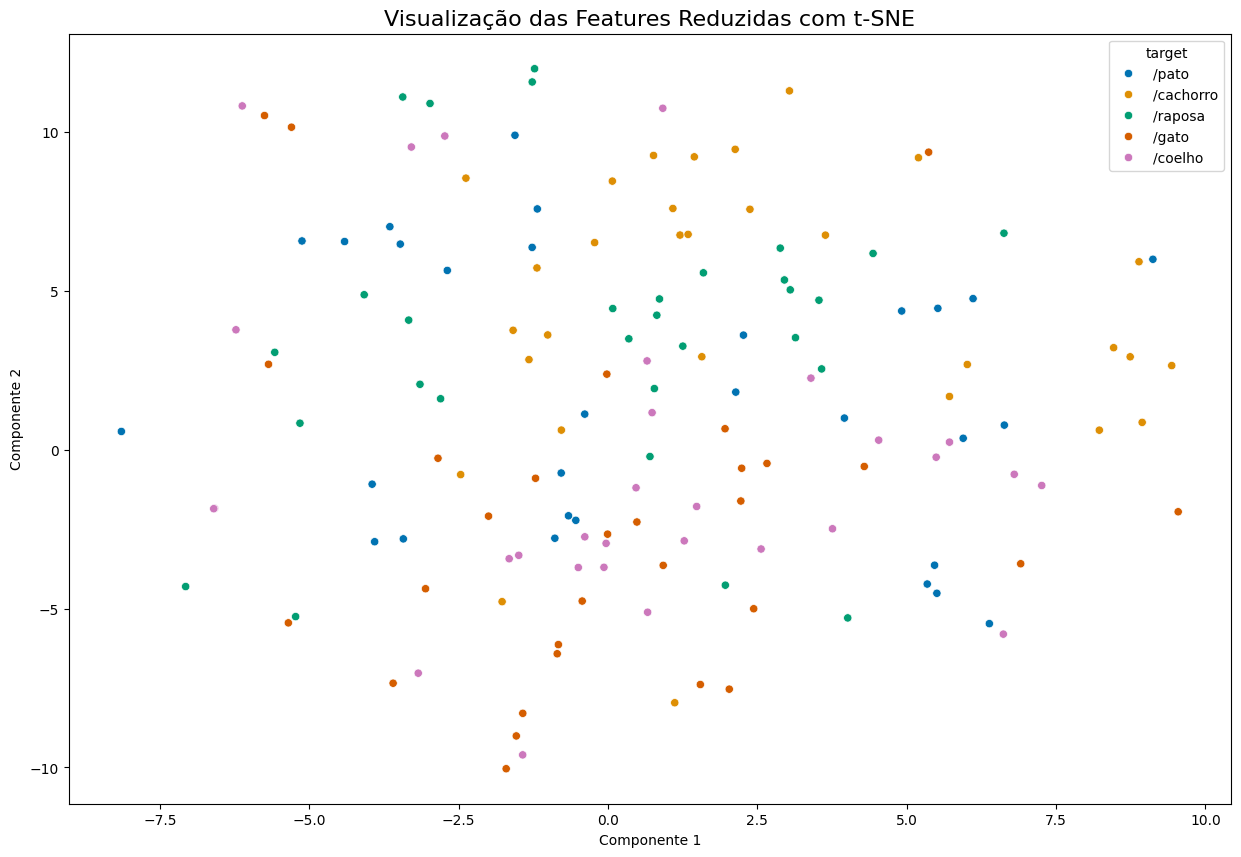

In [ ]:
# ===============================================================
# 1. Aplicando o t-SNE para reduzir as features para 2 dimensões
# ===============================================================
# n_components=2 -> queremos visualizar em um gráfico 2D
# learning_rate='auto' -> taxa de aprendizado definida automaticamente
# init='random' -> inicialização aleatória dos pontos
# perplexity=15 -> parâmetro que controla a noção de vizinhança
from sklearn.manifold import TSNE

model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=15)

# Aplica o t-SNE sobre o DataFrame de features
array_red = model.fit_transform(df_features)

# ===============================================================
# 2. Criando um DataFrame com as coordenadas reduzidas
# ===============================================================
df_tsne = pd.DataFrame(array_red)         # Colunas 0 e 1 são as novas dimensões
df_tsne['target'] = target                # Adiciona a coluna de classes

# ===============================================================
# 3. Configurando o tamanho do gráfico
# ===============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = [15, 10]  # Define tamanho da figura

# ===============================================================
# 4. Criando o gráfico de dispersão
# ===============================================================
sns.scatterplot(
    data=df_tsne,
    x=df_tsne[0],        # Eixo X
    y=df_tsne[1],        # Eixo Y
    hue=df_tsne['target'],  # Cor de cada ponto de acordo com a classe
    palette="colorblind"    # Paleta amigável para daltônicos
)

# Exibe o gráfico
plt.title("Visualização das Features Reduzidas com t-SNE", fontsize=16)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()


## 6. Treinando e Validando o Modelo

In [ ]:
def getModel():
    """
    Retorna um modelo de aprendizado de máquina para classificação.

    O usuário pode descomentar a linha do modelo desejado para utilizá-lo.

    Retorna:
    - Um classificador escolhido entre RandomForest, GaussianNB, Logistic Regression,
      KNN, XGBoost ou SGDClassifier.
    """

    # Retorna um classificador Naive Bayes Gaussiano (padrão)
    return GaussianNB()

    # Opções alternativas de modelos (descomente para utilizá-los):

    # Retorna um Random Forest Classifier com processamento paralelo
    # return RandomForestClassifier(n_jobs=12)

    # Retorna uma Regressão Logística com solver otimizado para grandes datasets
    # return LogisticRegression(n_jobs=20, solver='sag', multi_class='ovr')

    # Retorna um classificador KNN com 3 vizinhos e processamento paralelo
    # return KNeighborsClassifier(n_neighbors=3, n_jobs=20)

    # Retorna um classificador baseado em XGBoost
    # return XGBClassifier()

    # Retorna um SGDClassifier com early stopping e validação de 5% dos dados
    # return SGDClassifier(n_jobs=20, early_stopping=True, validation_fraction=0.05)

In [ ]:
# Divisão dos dados em conjunto de treino e teste
# - df_features.values -> Matriz de características extraídas das imagens (X)
# - target -> Rótulos das classes associadas a cada imagem (y)
# - test_size=percentege_test_size -> Define a proporção dos dados usados para teste (ex: 20% se percentege_test_size=0.2)
X_treino, X_teste, y_treino, y_teste = train_test_split(df_features.values, target, test_size=percentege_test_size)

# Obtém o modelo de aprendizado de máquina escolhido e realiza o treinamento
# - getModel() -> Função que retorna um classificador, como GaussianNB, RandomForest, KNN, etc.
# - fit(X_treino, y_treino) -> Treina o modelo nos dados de treino
model = getModel().fit(X_treino, y_treino)

# Avaliação do modelo no conjunto de teste
# - score() calcula a acurácia (proporção de previsões corretas no conjunto de teste)
score = model.score(X_teste, y_teste)

# Exibe a acurácia do modelo
score

0.7333333333333333

## 7. Validando de Forma Mais Elaborada


In [ ]:
# Avaliação do modelo utilizando validação cruzada com 10 folds
# - getModel() -> Obtém o modelo de aprendizado de máquina escolhido
# - df_features.values -> Matriz de características extraídas das imagens (X)
# - target -> Rótulos das classes (y)
# - cv=10 -> Realiza uma validação cruzada com 10 divisões (folds)
scores = cross_val_score(getModel(), df_features.values, target, cv=10)

# Calcula a média dos scores obtidos na validação cruzada
np.mean(scores)

np.float64(0.6266666666666667)

## 8. Visualizando a Matriz de Confusão


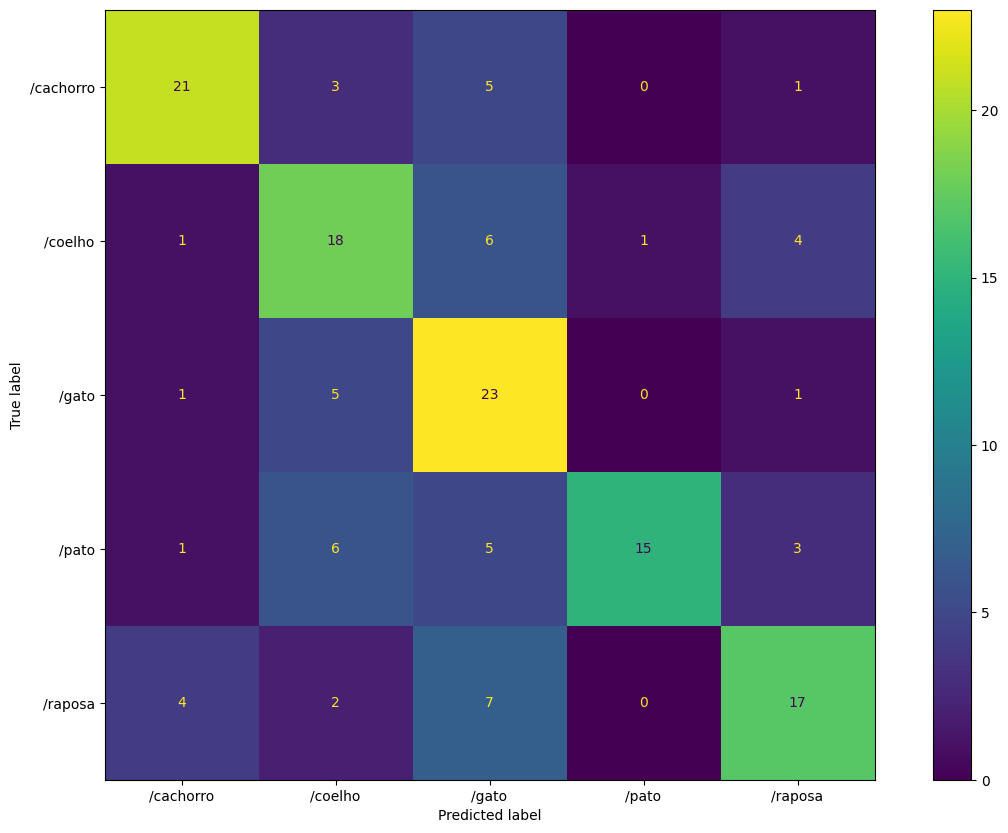

In [ ]:
# Realiza predições utilizando validação cruzada
# - getModel() -> Obtém o modelo escolhido (ex: GaussianNB, RandomForest, etc.)
# - df_features.values -> Matriz de características das imagens (X)
# - target -> Rótulos das classes (y)
# - cv=10 -> Realiza a validação cruzada com 10 folds
predicoes = cross_val_predict(getModel(), df_features.values, target, cv=10)

# Gera a matriz de confusão comparando os rótulos verdadeiros e as predições
cm = confusion_matrix(target, predicoes)

# Cria uma visualização da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

# Plota a matriz de confusão
disp.plot()

# Exibe o gráfico
plt.show()